## 0. Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
# general
from pathlib import Path

import geopandas as gpd

# for plotting and coloring
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from tqdm.notebook import tqdm

gpd.options.io_engine = "pyogrio"

In [3]:
from gridsample.utils import create_gmap_links, save_shapefiles, create_ids
# from gridsample.mapping import create_interactive_map

In [38]:
from utils import (
    download_VIDA_rooftops_data_by_s2,
    generate_colormap,
    get_matched_rooftop_centroids_from_s2_file,
    get_s2_cell_ids_from_points,
    get_s2_cell_ids,
    s2_cell_ids_to_shapes_gdf,
)

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_ifa"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
PROCESSED_DATA_DIR = DATA_DIR / "02. Processed Data"
OUTPUT_DATA_DIR = DATA_DIR / "03. Output Data" / "Pilot 1"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

Need to also symlink the VIDA rooftop data folder inside Raw Data. MacOS:

    ln -s "/Users/amiremami/IDinsight Dropbox/Amir Emami/VIDA S2 Rooftop Data" "VIDA S2 Rooftop Data"

## 1. Load training areas

<Axes: >

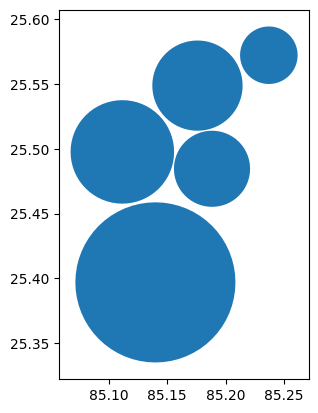

In [6]:
rural_shapes_gdf = gpd.read_file(RAW_DATA_DIR / "pilot" / "Rural.geojson").to_crs(4326)
rural_shapes_gdf["high_density"] = 0
rural_shapes_gdf.plot()

<Axes: >

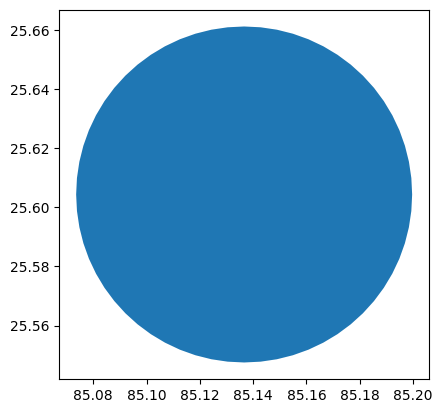

In [21]:
urban_shapes_gdf = gpd.read_file(RAW_DATA_DIR / "pilot" / "Urban.geojson").to_crs(4326)
urban_shapes_gdf["high_density"] = 1
urban_shapes_gdf.plot()

In [22]:
shapes_gdf = pd.concat([rural_shapes_gdf, urban_shapes_gdf], ignore_index=True)
shapes_gdf["shape_id"] = create_ids(len(shapes_gdf), prefix="shape_")
# if rural, add _r to the shape ID, else add _u
shapes_gdf["shape_id"] = shapes_gdf.apply(
    lambda row: row["shape_id"] + ("_r" if row["high_density"] == 0 else "_u"), axis=1
)

<Axes: >

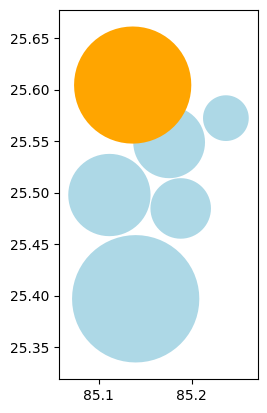

In [23]:
shapes_gdf.plot(column="high_density", cmap=ListedColormap(["lightblue", "orange"]))

In [24]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = (
    RAW_DATA_DIR / "Admin Boundaries" / "shrug-pc11subdist-poly-shp" / "subdistrict.shp"
)
subdistrict_gdf = gpd.read_file(boundaries_dir).to_crs(4326)

In [25]:
gdf = shapes_gdf.sjoin(subdistrict_gdf, how="left", predicate="intersects").drop_duplicates(subset=["shape_id"]).drop(columns="index_right")

In [26]:
gdf

,geometry,high_density,shape_id,pc11_s_id,pc11_d_id,pc11_sd_id,sd_name
0,"POLYGON ((85.17581 25.58362, 85.17203 25.58345...",0,shape_1_r,10,230,01401,Sampatchak
1,"POLYGON ((85.23684 25.59443, 85.23442 25.59433...",0,shape_2_r,10,220,01279,Raghopur
2,"POLYGON ((85.18826 25.51399, 85.18507 25.51385...",0,shape_3_r,10,230,01411,Fatwah
3,"POLYGON ((85.11160 25.53757, 85.10726 25.53738...",0,shape_4_r,10,230,01410,Punpun
4,"POLYGON ((85.13986 25.45874, 85.13315 25.45844...",0,shape_5_r,10,230,01412,Daniawan
5,"POLYGON ((85.13663 25.66120, 85.13045 25.66092...",1,shape_6_u,10,230,01401,Sampatchak


### 2.1 Rename and clean both datasets

In [27]:
gdf.rename(columns={
    "pc11_s_id": "state",
    "pc11_d_id": "district",
    "pc11_sd_id": "subdistrict",
    "sd_name": "subdistrict_name"
    }, inplace=True)

In [28]:
# make relevant codes into floats for both datasets
code_columns = [
    "state",
    "district",
    "subdistrict",
]
for col in code_columns:
    gdf[col] = gdf[col].astype(int)

## 3. Filter boundaries to sampled areas

In [29]:
# filter based on state/district/subdistrict codes
filtered_gdf = gdf.copy()

In [30]:
filtered_gdf["state_name"] = filtered_gdf["state"].map(
    {
        10: "Bihar",
    }
)

In [31]:
filtered_gdf

,geometry,high_density,shape_id,state,district,subdistrict,subdistrict_name,state_name
0,"POLYGON ((85.17581 25.58362, 85.17203 25.58345...",0,shape_1_r,10,230,1401,Sampatchak,Bihar
1,"POLYGON ((85.23684 25.59443, 85.23442 25.59433...",0,shape_2_r,10,220,1279,Raghopur,Bihar
2,"POLYGON ((85.18826 25.51399, 85.18507 25.51385...",0,shape_3_r,10,230,1411,Fatwah,Bihar
3,"POLYGON ((85.11160 25.53757, 85.10726 25.53738...",0,shape_4_r,10,230,1410,Punpun,Bihar
4,"POLYGON ((85.13986 25.45874, 85.13315 25.45844...",0,shape_5_r,10,230,1412,Daniawan,Bihar
5,"POLYGON ((85.13663 25.66120, 85.13045 25.66092...",1,shape_6_u,10,230,1401,Sampatchak,Bihar


## 5. Download rooftops

#### Identify S2 cell IDs

In [43]:
s2_cell_ids = get_s2_cell_ids(filtered_gdf)
len(s2_cell_ids)

All shapes fully covered in round 1.


<string>:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



2

#### Check if identified cells cover all areas of interest

In [44]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [45]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = filtered_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


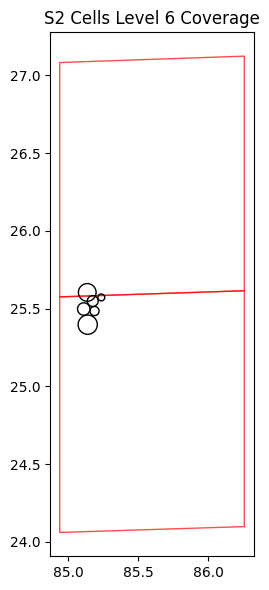

In [46]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
filtered_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [47]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        filtered_gdf[["state_name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

In [48]:
# note: this will have duplicate s2 cell rows with different states if the s2 cell overlaps multiple states
# this is expected and is required for the next steps logic to work correctly
s2_cells_gdf_w_state

,s2_cell_id,geometry,state_name
0,4175681279502581760,"POLYGON ((84.94013 24.06054, 86.25649 24.09829...",Bihar
1,4173992429642317824,"POLYGON ((84.94013 25.57561, 86.25649 25.61509...",Bihar


#### Download the S2 cells

In [49]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "VIDA S2 Rooftop Data" / "Available")

File 4175681279502581760 already exists.
File 4173992429642317824 already exists.


## 6. Load rooftops and match to areas

In [50]:
state_names = filtered_gdf["state_name"].sort_values().unique()

In [58]:
for state_name in tqdm(state_names):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["state_name"] == state_name][
            "s2_cell_id"
        ]
    )
    print(
        f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
    )
    gdf_subset = filtered_gdf[filtered_gdf["state_name"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_file_dir=RAW_DATA_DIR / "VIDA S2 Rooftop Data" / "Available",
            s2_cell_id=s2_cell_id,
            boundaries_gdf=gdf_subset,
        )
        matched_rooftop_centroids_gdf.drop(
            columns=[
                "boundary_id",
                "bf_source",
                "confidence",
                "area_in_meters",
                "s2_id",
                "country_iso",
                "geohash",
                "bbox",
            ],
            inplace=True,
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["state_name"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        PROCESSED_DATA_DIR / "01. Matched Rooftop Data - Pilot 1" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

  0%|          | 0/1 [00:00<?, ?it/s]

Processing state: Bihar
Number of S2 cells that overlap our shapes in Bihar: 2


  0%|          | 0/2 [00:00<?, ?it/s]

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:235: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf = gpd.read_parquet(s2_rooftops_path)
/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:235: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf = gpd.read_parquet(s2_rooftops_path)


<Axes: >

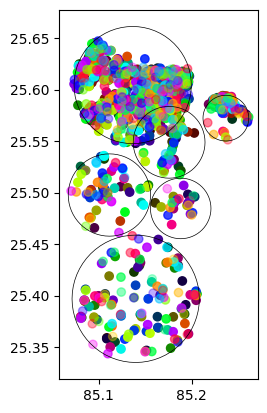

In [52]:
ax = matched_rooftop_centroids_gdf.sample(1000).plot(
    cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
)
gdf_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [53]:
matched_rooftop_dir = PROCESSED_DATA_DIR / "01. Matched Rooftop Data - Pilot 1"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# filter to those that have selected_states in the name
all_filepaths = [
    f for f in all_filepaths if any(state in f.parent.name for state in state_names)
]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

  0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
len(matched_rooftops_gdf)

494799

In [60]:
matched_rooftops_gdf["overall_rooftop_id"] = create_ids(
    len(matched_rooftops_gdf), prefix="rooftop_"
)

In [61]:
no_rooftop_subdistrict_IDs = set(filtered_gdf[filtered_gdf["state"].isin(state_names)]["subdistrict"].unique()).difference(
    set(matched_rooftops_gdf["subdistrict"].unique())
)
no_rooftop_subdistrict_gdf = filtered_gdf[filtered_gdf["subdistrict"].isin(no_rooftop_subdistrict_IDs)]
no_rooftop_subdistrict_gdf

,geometry,high_density,shape_id,state,district,subdistrict,subdistrict_name,state_name


In [62]:
if len(no_rooftop_subdistrict_gdf) > 0:
    print("Saving subdistricts with no rooftops...")
    save_shapefiles(
        no_rooftop_subdistrict_gdf,
        OUTPUT_DATA_DIR / "Sampled Subdistricts",
        "subdistricts_with_no_rooftops",
        ["csv", "kml"],
    )

## 8. Sample rooftops

In [83]:
# Define the base number of rooftops per rural/urban
ROOFTOPS_PER_TYPE = {
    0: 10,  # rural
    1: 50,  # urban
}

# Sample rooftops: sample per shape, using the correct number for rural/urban
sampled_rooftops_gdf = matched_rooftops_gdf.groupby(
    "shape_id", group_keys=False
).apply(
    lambda x: x.sample(
        n=min(ROOFTOPS_PER_TYPE[x["high_density"].iloc[0]], x.shape[0]),
        random_state=42,
    )
)

In [84]:
sampled_rooftops_gdf.groupby(["shape_id"]).size()

shape_id
shape_1_r    10
shape_2_r    10
shape_3_r    10
shape_4_r    10
shape_5_r    10
shape_6_u    50
dtype: int64

In [86]:
print("Length of matched_rooftops_gdf:", len(matched_rooftops_gdf))
print("Length of sampled rooftops:", len(sampled_rooftops_gdf))

Length of matched_rooftops_gdf: 494799
Length of sampled rooftops: 100


<Axes: >

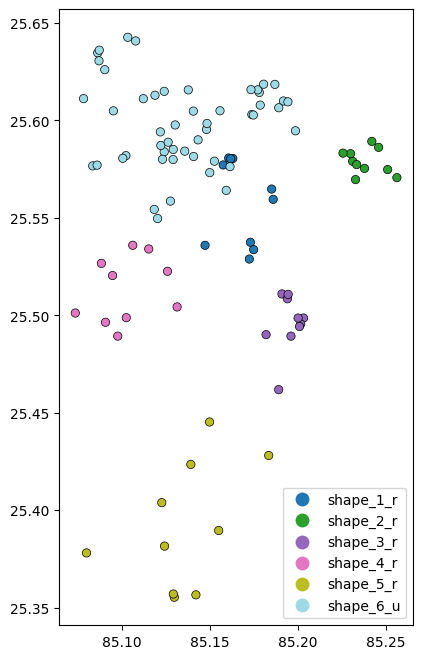

In [87]:
sampled_rooftops_gdf.plot(
    figsize=(8, 8),
    column="shape_id",
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [88]:
# Rooftop number within each subdistrict
sampled_rooftops_gdf["Rooftop Shape ID Numeric"] = sampled_rooftops_gdf.groupby("shape_id").cumcount() + 1

## Find nearest neighbour replacement pins

Using efficient KD-tree algorithm to find 20 nearest rooftops for each sampled rooftop.

In [89]:
from utils import find_k_nearest_rooftops

In [90]:
# Example usage: Find 20 nearest rooftops for each sampled rooftop
# Note: Adjust the variable names based on what you have in your notebook

# Find k=20 nearest neighbours
neighbours_df = find_k_nearest_rooftops(
    all_rooftops_gdf=matched_rooftops_gdf[
        matched_rooftops_gdf["high_density"] == 0
    ],  # All rural rooftops
    sampled_rooftops_gdf=sampled_rooftops_gdf[
        sampled_rooftops_gdf["high_density"] == 0
    ],  # sampled rural rooftops
    k=20,
    max_distance_m=2000,  # Optional: only include neighbours within 2km
)

# Display results
print(f"\nTotal neighbour relationships: {len(neighbours_df):,}")
print(
    f"Average neighbours per sample: {len(neighbours_df) / len(sampled_rooftops_gdf[
        sampled_rooftops_gdf["high_density"] == 0
    ]):.1f}"
)
neighbours_df.head(25)

Using CRS: EPSG:32645
Projecting coordinates to UTM...
Building KD-tree for 187,424 points...
Querying 50 points for k=20 neighbors...
Found 1,000 neighbour relationships

Total neighbour relationships: 1,000
Average neighbours per sample: 20.0


,sampled_idx,neighbour_idx,Distance from Original (m),Neighbour Rank
0,141619,141614,14.20,1
1,141619,141617,18.23,2
2,141619,141618,19.12,3
3,141619,140871,21.46,4
4,141619,141620,26.08,5
5,141619,141613,29.13,6
6,141619,140872,33.43,7
7,141619,141624,36.35,8
8,141619,141625,37.07,9
9,141619,140873,37.33,10


In [91]:
neighbours_df

,sampled_idx,neighbour_idx,Distance from Original (m),Neighbour Rank
0,141619,141614,14.20,1
1,141619,141617,18.23,2
2,141619,141618,19.12,3
3,141619,140871,21.46,4
4,141619,141620,26.08,5
...,...,...,...,...
995,6913,6953,16.78,16
996,6913,6911,16.81,17
997,6913,6954,16.90,18
998,6913,6943,17.08,19


In [92]:
# filter neighbours to only those that are NOT also in the sampled rooftops
neighbours_df = neighbours_df[~neighbours_df["neighbour_idx"].isin(neighbours_df["sampled_idx"].unique())]
# drop second instances of a neighbour belonging to multiple sampled rooftops
neighbours_df = neighbours_df.drop_duplicates(subset=["neighbour_idx"])

In [93]:
neighbours_df

,sampled_idx,neighbour_idx,Distance from Original (m),Neighbour Rank
0,141619,141614,14.20,1
1,141619,141617,18.23,2
2,141619,141618,19.12,3
3,141619,140871,21.46,4
4,141619,141620,26.08,5
...,...,...,...,...
995,6913,6953,16.78,16
996,6913,6911,16.81,17
997,6913,6954,16.90,18
998,6913,6943,17.08,19


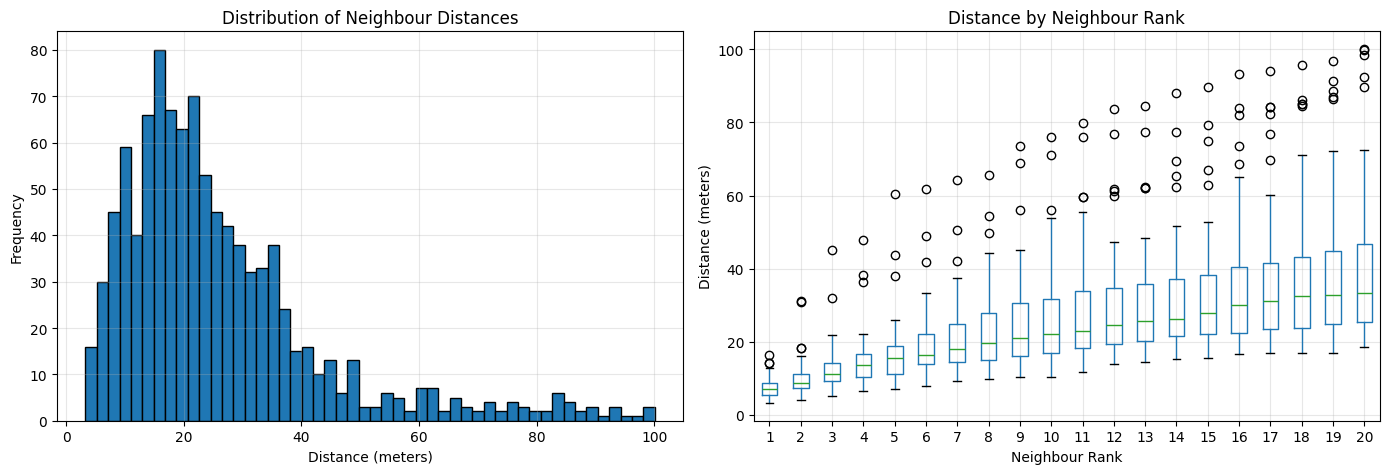

In [94]:
# Visualize distance distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance distribution
axes[0].hist(neighbours_df['Distance from Original (m)'], bins=50, edgecolor='black')
axes[0].set_xlabel('Distance (meters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Neighbour Distances')
axes[0].grid(True, alpha=0.3)

# Distance by rank
neighbours_df.boxplot(column='Distance from Original (m)', by='Neighbour Rank', ax=axes[1])
axes[1].set_xlabel('Neighbour Rank')
axes[1].set_ylabel('Distance (meters)')
axes[1].set_title('Distance by Neighbour Rank')
axes[1].grid(True, alpha=0.3)
plt.suptitle('')  # Remove auto-generated title

plt.tight_layout()
plt.show()

In [95]:
# add metadata for all neighbours
neighbours_with_details = neighbours_df.merge(
    matched_rooftops_gdf,
    left_on='neighbour_idx',
    right_index=True,
    how='left',
)
neighbours_with_details.head()

,sampled_idx,neighbour_idx,Distance from Original (m),Neighbour Rank,geometry,high_density,shape_id,state,district,subdistrict,subdistrict_name,state_name,overall_rooftop_id
0,141619,141614,14.20,1,POINT (85.16062 25.58059),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141615
1,141619,141617,18.23,2,POINT (85.16085 25.58064),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141618
2,141619,141618,19.12,3,POINT (85.16085 25.58078),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141619
3,141619,140871,21.46,4,POINT (85.16049 25.58061),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_140872
4,141619,141620,26.08,5,POINT (85.16087 25.58086),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141621


In [96]:
# add original rooftop IDs for neighbours
neighbours_with_details = neighbours_with_details.merge(
    matched_rooftops_gdf["overall_rooftop_id"],
    left_on="sampled_idx",
    right_index=True,
    how="left",
    suffixes=("", "_original"),
)
neighbours_with_details.head()

,sampled_idx,neighbour_idx,Distance from Original (m),Neighbour Rank,geometry,high_density,shape_id,state,district,subdistrict,subdistrict_name,state_name,overall_rooftop_id,overall_rooftop_id_original
0,141619,141614,14.20,1,POINT (85.16062 25.58059),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141615,rooftop_141620
1,141619,141617,18.23,2,POINT (85.16085 25.58064),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141618,rooftop_141620
2,141619,141618,19.12,3,POINT (85.16085 25.58078),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141619,rooftop_141620
3,141619,140871,21.46,4,POINT (85.16049 25.58061),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_140872,rooftop_141620
4,141619,141620,26.08,5,POINT (85.16087 25.58086),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141621,rooftop_141620


In [97]:
neighbours_with_details.isna().sum()

sampled_idx                    0
neighbour_idx                  0
Distance from Original (m)     0
Neighbour Rank                 0
geometry                       0
high_density                   0
shape_id                       0
state                          0
district                       0
subdistrict                    0
subdistrict_name               0
state_name                     0
overall_rooftop_id             0
overall_rooftop_id_original    0
dtype: int64

In [98]:
set(neighbours_with_details["overall_rooftop_id_original"].unique()).difference(set(sampled_rooftops_gdf["overall_rooftop_id"].unique()))

set()

In [99]:
# add Rooftop Shape ID based on matching overall_rooftop_id_original
neighbours_with_details["Rooftop Shape ID Numeric"] = neighbours_with_details[
    "overall_rooftop_id_original"
].map(sampled_rooftops_gdf.set_index("overall_rooftop_id")["Rooftop Shape ID Numeric"])

In [100]:
neighbours_with_details.isna().sum()

sampled_idx                    0
neighbour_idx                  0
Distance from Original (m)     0
Neighbour Rank                 0
geometry                       0
high_density                   0
shape_id                       0
state                          0
district                       0
subdistrict                    0
subdistrict_name               0
state_name                     0
overall_rooftop_id             0
overall_rooftop_id_original    0
Rooftop Shape ID Numeric       0
dtype: int64

### Add the navigation pins to the sampled set

Update rural pins to have IDs like `PIN_1_1, PIN_2_1, ...` and then label the neighbours of `PIN_1_1` as `PIN_1_2, PIN_1_3, ...`

In [101]:
sampled_rooftops_gdf["Neighbour Rank"] = 0
sampled_rooftops_gdf["Distance from Original (m)"] = 0

In [102]:
# order columns to match sampled_rooftops_gdf
neighbours_final = neighbours_with_details[sampled_rooftops_gdf.columns]

In [103]:
combined_sampled_and_neighbours_gdf = pd.concat(
    [sampled_rooftops_gdf, neighbours_final], ignore_index=True
)
combined_sampled_and_neighbours_gdf["Distance from Original (m)"] = (
    combined_sampled_and_neighbours_gdf["Distance from Original (m)"].round(2)
)

In [104]:
sorted_sampled_and_neighbours_gdf = combined_sampled_and_neighbours_gdf.sort_values(
    by=["shape_id", "Rooftop Shape ID Numeric", "Neighbour Rank"],
    ignore_index=True,
)
sorted_sampled_and_neighbours_gdf

,geometry,high_density,shape_id,state,district,subdistrict,subdistrict_name,state_name,overall_rooftop_id,Rooftop Shape ID Numeric,Neighbour Rank,Distance from Original (m)
0,POINT (85.16068 25.58070),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141620,1,0,0.00
1,POINT (85.16062 25.58059),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141615,1,1,14.20
2,POINT (85.16085 25.58064),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141618,1,2,18.23
3,POINT (85.16085 25.58078),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141619,1,3,19.12
4,POINT (85.16049 25.58061),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_140872,1,4,21.46
...,...,...,...,...,...,...,...,...,...,...,...,...
1095,POINT (85.14834 25.59844),1,shape_6_u,10,230,1401,Sampatchak,Bihar,rooftop_342432,46,0,0.00
1096,POINT (85.15929 25.56410),1,shape_6_u,10,230,1401,Sampatchak,Bihar,rooftop_177124,47,0,0.00
1097,POINT (85.08586 25.57706),1,shape_6_u,10,230,1401,Sampatchak,Bihar,rooftop_187163,48,0,0.00
1098,POINT (85.11835 25.55432),1,shape_6_u,10,230,1401,Sampatchak,Bihar,rooftop_152652,49,0,0.00


In [105]:
# Make unique Pin IDs
sorted_sampled_and_neighbours_gdf.loc[sorted_sampled_and_neighbours_gdf["high_density"] == 1, "Pin ID"] = (
    "PIN_" + sorted_sampled_and_neighbours_gdf["Rooftop Shape ID Numeric"].astype(str)
)
sorted_sampled_and_neighbours_gdf.loc[sorted_sampled_and_neighbours_gdf["high_density"] == 0, "Pin ID"] = (
    "PIN_"
    + sorted_sampled_and_neighbours_gdf["Rooftop Shape ID Numeric"].astype(str)
    + "_"
    + sorted_sampled_and_neighbours_gdf["Neighbour Rank"].astype(str)
)

In [106]:
sorted_sampled_and_neighbours_gdf

,geometry,high_density,shape_id,state,district,subdistrict,subdistrict_name,state_name,overall_rooftop_id,Rooftop Shape ID Numeric,Neighbour Rank,Distance from Original (m),Pin ID
0,POINT (85.16068 25.58070),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141620,1,0,0.00,PIN_1_0
1,POINT (85.16062 25.58059),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141615,1,1,14.20,PIN_1_1
2,POINT (85.16085 25.58064),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141618,1,2,18.23,PIN_1_2
3,POINT (85.16085 25.58078),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_141619,1,3,19.12,PIN_1_3
4,POINT (85.16049 25.58061),0,shape_1_r,10,230,1401,Sampatchak,Bihar,rooftop_140872,1,4,21.46,PIN_1_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,POINT (85.14834 25.59844),1,shape_6_u,10,230,1401,Sampatchak,Bihar,rooftop_342432,46,0,0.00,PIN_46
1096,POINT (85.15929 25.56410),1,shape_6_u,10,230,1401,Sampatchak,Bihar,rooftop_177124,47,0,0.00,PIN_47
1097,POINT (85.08586 25.57706),1,shape_6_u,10,230,1401,Sampatchak,Bihar,rooftop_187163,48,0,0.00,PIN_48
1098,POINT (85.11835 25.55432),1,shape_6_u,10,230,1401,Sampatchak,Bihar,rooftop_152652,49,0,0.00,PIN_49


In [107]:
sorted_sampled_and_neighbours_gdf.isna().sum()

geometry                      0
high_density                  0
shape_id                      0
state                         0
district                      0
subdistrict                   0
subdistrict_name              0
state_name                    0
overall_rooftop_id            0
Rooftop Shape ID Numeric      0
Neighbour Rank                0
Distance from Original (m)    0
Pin ID                        0
dtype: int64

In [108]:
# Rooftop Unique ID
sorted_sampled_and_neighbours_gdf["Rooftop Unique ID"] = sorted_sampled_and_neighbours_gdf.apply(
    lambda row: f"{row['shape_id']}_{row['Pin ID']}",
    axis=1,
)

In [109]:
sampled_rooftops_gdf_old = sampled_rooftops_gdf.copy()
sampled_rooftops_gdf = sorted_sampled_and_neighbours_gdf.copy()

### Add gmap link

In [110]:
sampled_rooftops_gdf["latitude_original"] = sampled_rooftops_gdf.geometry.y
sampled_rooftops_gdf["longitude_original"] = sampled_rooftops_gdf.geometry.x
sampled_rooftops_gdf["gmap_link_original"] = create_gmap_links(
    df=sampled_rooftops_gdf,
    lat_name="latitude_original",
    lon_name="longitude_original",
)

### Select only useful columns

In [111]:
sampled_rooftops_gdf.columns

Index(['geometry', 'high_density', 'shape_id', 'state', 'district',
       'subdistrict', 'subdistrict_name', 'state_name', 'overall_rooftop_id',
       'Rooftop Shape ID Numeric', 'Neighbour Rank',
       'Distance from Original (m)', 'Pin ID', 'Rooftop Unique ID',
       'latitude_original', 'longitude_original', 'gmap_link_original'],
      dtype='object')

In [112]:
chosen_cols = [
    # IDs
    "shape_id",
    "Pin ID",
    "Rooftop Shape ID Numeric",
    "Neighbour Rank",
    "Rooftop Unique ID",
    "overall_rooftop_id",
    # Admin
    "state_name",
    "state",
    "district",
    "subdistrict",
    "subdistrict_name",
    "high_density",
    # Location
    "latitude_original",
    "longitude_original",
    "gmap_link_original",
    # Geometry
    "geometry",
]

In [113]:
sampled_rooftops_gdf = sampled_rooftops_gdf[chosen_cols]

In [114]:
sampled_rooftops_gdf

,shape_id,Pin ID,Rooftop Shape ID Numeric,Neighbour Rank,Rooftop Unique ID,overall_rooftop_id,state_name,state,district,subdistrict,subdistrict_name,high_density,latitude_original,longitude_original,gmap_link_original,geometry
0,shape_1_r,PIN_1_0,1,0,shape_1_r_PIN_1_0,rooftop_141620,Bihar,10,230,1401,Sampatchak,0,25.580702,85.160680,https://www.google.com/maps/search/?api=1&quer...,POINT (85.16068 25.58070)
1,shape_1_r,PIN_1_1,1,1,shape_1_r_PIN_1_1,rooftop_141615,Bihar,10,230,1401,Sampatchak,0,25.580586,85.160620,https://www.google.com/maps/search/?api=1&quer...,POINT (85.16062 25.58059)
2,shape_1_r,PIN_1_2,1,2,shape_1_r_PIN_1_2,rooftop_141618,Bihar,10,230,1401,Sampatchak,0,25.580641,85.160849,https://www.google.com/maps/search/?api=1&quer...,POINT (85.16085 25.58064)
3,shape_1_r,PIN_1_3,1,3,shape_1_r_PIN_1_3,rooftop_141619,Bihar,10,230,1401,Sampatchak,0,25.580781,85.160849,https://www.google.com/maps/search/?api=1&quer...,POINT (85.16085 25.58078)
4,shape_1_r,PIN_1_4,1,4,shape_1_r_PIN_1_4,rooftop_140872,Bihar,10,230,1401,Sampatchak,0,25.580613,85.160490,https://www.google.com/maps/search/?api=1&quer...,POINT (85.16049 25.58061)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,shape_6_u,PIN_46,46,0,shape_6_u_PIN_46,rooftop_342432,Bihar,10,230,1401,Sampatchak,1,25.598440,85.148344,https://www.google.com/maps/search/?api=1&quer...,POINT (85.14834 25.59844)
1096,shape_6_u,PIN_47,47,0,shape_6_u_PIN_47,rooftop_177124,Bihar,10,230,1401,Sampatchak,1,25.564102,85.159287,https://www.google.com/maps/search/?api=1&quer...,POINT (85.15929 25.56410)
1097,shape_6_u,PIN_48,48,0,shape_6_u_PIN_48,rooftop_187163,Bihar,10,230,1401,Sampatchak,1,25.577060,85.085856,https://www.google.com/maps/search/?api=1&quer...,POINT (85.08586 25.57706)
1098,shape_6_u,PIN_49,49,0,shape_6_u_PIN_49,rooftop_152652,Bihar,10,230,1401,Sampatchak,1,25.554321,85.118352,https://www.google.com/maps/search/?api=1&quer...,POINT (85.11835 25.55432)


### Save sampled data (original rooftop pins)

In [115]:
def save_partitioned_kmls(gdf, FOLDER_PATH, filename_prefix):
    """
    Save the sampled rooftops GeoDataFrame into multiple KML files,
    each containing a maximum of 1500 rows.
    """
    MAX_ROWS_PER_FILE = 1500
    n_partitions = (len(gdf) + MAX_ROWS_PER_FILE - 1) // MAX_ROWS_PER_FILE

    for partition_idx in range(n_partitions):
        start_idx = partition_idx * MAX_ROWS_PER_FILE
        end_idx = min((partition_idx + 1) * MAX_ROWS_PER_FILE, len(gdf))
        
        partition_gdf = gdf.iloc[start_idx:end_idx]
        
        save_shapefiles(
            partition_gdf,
            FOLDER_PATH,
            f"{filename_prefix}_part_{partition_idx + 1}",
            ["kml"],
        )

In [116]:
save_shapefiles(
    sampled_rooftops_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet"],
)

save_partitioned_kmls(
    sampled_rooftops_gdf.drop(columns=["gmap_link_original"]),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "Full Sample KMLs",
    "sampled_rooftops_centroids_original",
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroids_original_part_1.high_density: Lossy conversion occurred when trying to set 64 bit integer field from real value 85.160680377407886.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroids_original_part_1.high_density: Lossy conversion occurred when trying to set 64 bit integer field from real value 85.160620418976109.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroids_original_part_1.high_density: Lossy conversion occurred when trying to set 64 bit integer field from real value 85.160848780759295.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroi

#### DONE

Navigation pins:
- Match to orginal sample ID and 
- add new rooftop IDs to the neighbours 
- and insert them into the main sample


IDs:
- Pin numbering per subdistrict, 1, 2, 3, ...
- In rural, 1_1, 1_2, 1_3, ...

#### TO DO
Output files:
- Across all - slices of original then every 5 nav pins
- Per district, all?

## 9. Snap points to road

In [117]:
import yaml
from shapely import Point

from utils import get_nearest_points_on_road_batch, get_nearest_points_on_road_batch_parallel

In [118]:
# load API key
with open("../secrets/api_keys.yaml", "r") as f:
    config = yaml.safe_load(f)
    api_key = config["GOOGLE_ROADS_API_KEY"]

In [119]:
get_nearest_points_on_road_batch([Point(77.11432151622034, 28.677391409999522)], api_key)

[<POINT (77.114 28.677)>]

In [120]:
# test
get_nearest_points_on_road_batch(sampled_rooftops_gdf.geometry.iloc[:5], api_key)

[<POINT (85.161 25.581)>,
 <POINT (85.161 25.581)>,
 <POINT (85.161 25.581)>,
 <POINT (85.161 25.581)>,
 <POINT (85.16 25.58)>]

In [121]:
get_nearest_points_on_road_batch_parallel(sampled_rooftops_gdf.iloc[:150], api_key)

Snapping points to roads (batched):   0%|          | 0/2 [00:00<?, ?it/s]

0      POINT (85.16075 25.58070)
1      POINT (85.16074 25.58058)
2      POINT (85.16074 25.58065)
3      POINT (85.16076 25.58079)
4      POINT (85.16048 25.58049)
                 ...            
145    POINT (85.16224 25.58015)
146    POINT (85.16224 25.58028)
147    POINT (85.17321 25.53742)
148    POINT (85.17321 25.53741)
149    POINT (85.17322 25.53746)
Length: 150, dtype: geometry

#### Snap points to road

In [122]:
snapped_points_series = get_nearest_points_on_road_batch_parallel(
    sampled_rooftops_gdf, api_key, max_workers=12
)
# took 1 second for 1,600 points (Panel)
# 30s for all 53,000 points 

Snapping points to roads (batched):   0%|          | 0/11 [00:00<?, ?it/s]

In [123]:
sampled_rooftops_snapped_gdf = sampled_rooftops_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = sampled_rooftops_snapped_gdf.index.map(snapped_points_series)

In [124]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

Geometry Type
Snapped to Road    1099
Original              1
Name: count, dtype: int64

#### Replace geometry to snapped one (missing filled in with original)

In [125]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [126]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

0

#### Update lat, lon, gmap_link

In [127]:
sampled_rooftops_snapped_gdf["latitude"] = list(sampled_rooftops_snapped_gdf.geometry.y)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Make lines between original and snapped points

In [128]:
from shapely.geometry import LineString

In [129]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [130]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

0

#### Save new files: snapped points, snapped lines

In [131]:
# Save CSV and parquet
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet"],
)

In [132]:
# Save KML
# save_shapefiles(
#     sampled_rooftops_snapped_gdf.drop(
#         columns=[
#             "geometry_original",
#             "geometry_line",
#             # bad cols for KML
#             "gmap_link_original",
#             "gmap_link"
#         ]
#     ),
#     OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
#     "sampled_rooftops_snapped_points",
#     ["kml"],
# )

save_partitioned_kmls(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
            # bad cols for KML
            "gmap_link_original",
            "gmap_link"
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points_part_1.high_density: Lossy conversion occurred when trying to set 64 bit integer field from real value 85.160680377407886.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Snapped to Road' of field sampled_rooftops_snapped_points_part_1.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points_part_1.high_density: Lossy conversion occurred when trying to set 64 bit integer field from real value 85.160620418976109.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points_part_1.high_density: Lossy conversion occurr

In [133]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
sampled_rooftops_line_gdf = sampled_rooftops_line_gdf.drop(
    columns=["geometry_original", "geometry_line"]
)

In [134]:
save_shapefiles(
    sampled_rooftops_line_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["parquet"],
)

save_partitioned_kmls(
    sampled_rooftops_line_gdf.drop(
        # drop kml unfriendly columns
        columns=["gmap_link_original", "gmap_link"]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines_part_1.high_density: Lossy conversion occurred when trying to set 64 bit integer field from real value 85.160680377407886.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Snapped to Road' of field sampled_rooftops_snapped_lines_part_1.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines_part_1.high_density: Lossy conversion occurred when trying to set 64 bit integer field from real value 85.160620418976109.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines_part_1.high_density: Lossy conversion occurred w

## Save per state

In [135]:
# for state in tqdm(sampled_rooftops_gdf["state_name"].unique()):
#     state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / state

#     # save original points
#     selected_state_original_gdf = sampled_rooftops_gdf[
#         sampled_rooftops_gdf["state_name"] == state
#     ]

#     save_shapefiles(
#         selected_state_original_gdf,
#         state_output_folder,
#         f"{state}_sampled_rooftops_centroids_original",
#         ["csv", "parquet"],
#     )
#     save_shapefiles(
#         selected_state_original_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original"]
#         ),
#         state_output_folder,
#         f"{state}_sampled_rooftops_centroids_original",
#         ["kml"],
#     )

#     # Save snapped points
#     selected_state_snapped_gdf = sampled_rooftops_snapped_gdf[
#         sampled_rooftops_snapped_gdf["state_name"] == state
#     ].drop(
#         columns=[
#             "geometry_original",
#             "geometry_line",
#         ]
#     )
#     save_shapefiles(
#         selected_state_snapped_gdf,
#         state_output_folder,
#         f"{state}_sampled_rooftops_snapped_points",
#         ["csv", "parquet"],
#     )
#     # save_shapefiles(
#     #     selected_state_snapped_gdf.drop(
#     #         # drop kml unfriendly columns
#     #         columns=["gmap_link_original", "gmap_link"]
#     #     ),
#     #     state_output_folder,
#     #     f"{state}_sampled_rooftops_snapped_points",
#     #     ["kml"],
#     # )

#     save_partitioned_kmls(
#         selected_state_snapped_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original", "gmap_link"]
#         ),
#         state_output_folder,
#         f"{state}_sampled_rooftops_snapped_points",
#     )

#     # Save lines
#     selected_state_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
#         sampled_rooftops_line_gdf["state_name"] == state
#     ]
#     save_shapefiles(
#         selected_state_sampled_rooftops_line_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original", "gmap_link"]
#         ),
#         state_output_folder,
#         f"{state}_sampled_rooftops_snapped_lines",
#         ["parquet"],
#     )

#     save_partitioned_kmls(
#         selected_state_sampled_rooftops_line_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original", "gmap_link"]
#         ),
#         state_output_folder,
#         f"{state}_sampled_rooftops_snapped_lines",
#     )

### Save slices per state

In [ ]:
# from math import ceil
# SLICE_SIZE = 25
# N_SLICES = ceil(ROOFTOPS_PER_SUBDISTRICT / SLICE_SIZE)

# print(f"ROOFTOPS_PER_SUBDISTRICT: {ROOFTOPS_PER_SUBDISTRICT}")
# print(f"SLICE_SIZE: {SLICE_SIZE}")
# print(f"N_SLICES: {N_SLICES}")
# print(f"N_SLICES * SLICE_SIZE: {N_SLICES * SLICE_SIZE}")

In [ ]:
# sampled_rooftops_gdf["state"].unique()

In [ ]:
# for state in tqdm(sampled_rooftops_gdf["state"].unique()):
#     state_gdf = sampled_rooftops_gdf[
#         sampled_rooftops_gdf["state"] == state
#     ]
#     for slice_idx in range(N_SLICES):

#         original_points_slice_rows = []
#         snapped_points_slice_rows = []
#         line_slice_rows = []

#         for psu_id, psu_df in state_gdf.groupby("subdistrict"):
#             # get counts and indices from the original dataframe (also applies to the other two)
#             ward_count = int(psu_df["Ward Count"].iloc[0])
#             start_idx = slice_idx * SLICE_SIZE * ward_count
#             end_idx = start_idx + (SLICE_SIZE * ward_count)

#             # original points
#             psu_original_slice = sampled_rooftops_gdf[
#                 (sampled_rooftops_gdf["state"] == state)
#                 & (sampled_rooftops_gdf["subdistrict"] == psu_id)
#             ].iloc[start_idx:end_idx]
#             original_points_slice_rows.append(psu_original_slice)

#             # snapped points
#             psu_snapped_slice = sampled_rooftops_snapped_gdf[
#                 (sampled_rooftops_snapped_gdf["state"] == state)
#                 & (sampled_rooftops_snapped_gdf["subdistrict"] == psu_id)
#             ].iloc[start_idx:end_idx]
#             snapped_points_slice_rows.append(psu_snapped_slice)

#             # lines
#             psu_line_slice = sampled_rooftops_line_gdf[
#                 (sampled_rooftops_line_gdf["state"] == state)
#                 & (sampled_rooftops_line_gdf["subdistrict"] == psu_id)
#             ].iloc[start_idx:end_idx]
#             line_slice_rows.append(psu_line_slice)


#         # Concatenate all PSU slices for this state and slice
#         state_slice_original_gdf = pd.concat(original_points_slice_rows, ignore_index=True)
#         state_slice_snapped_gdf = pd.concat(snapped_points_slice_rows, ignore_index=True)
#         state_slice_line_gdf = pd.concat(line_slice_rows, ignore_index=True)

#         # set folder
#         state_slice_output_folder = (
#             OUTPUT_DATA_DIR
#             / "01. Sampled Rooftop Data"
#             / state
#             / f"slice_{slice_idx}"
#         )

#         # Save original points
#         save_shapefiles(
#             state_slice_original_gdf,
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_centroids_original_{slice_idx}",
#             ["csv", "parquet"],
#         )
#         save_shapefiles(
#             state_slice_original_gdf.drop(columns=["gmap_link_original"]),
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_centroids_original_{slice_idx}",
#             ["kml"],
#         )

#         # Save snapped points
#         save_shapefiles(
#             state_slice_snapped_gdf,
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_snapped_points_{slice_idx}",
#             ["csv", "parquet"],
#         )
#         save_shapefiles(
#             state_slice_snapped_gdf.drop(
#                 # drop kml unfriendly columns
#                 columns=["gmap_link_original", "gmap_link", "geometry_line", "geometry_original"]
#             ),
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_snapped_points_{slice_idx}",
#             ["kml"],
#         )

#         # Save lines
#         save_shapefiles(
#             state_slice_line_gdf.drop(
#                 # drop kml unfriendly columns
#                 columns=["gmap_link_original", "gmap_link"]
#             ),
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_snapped_lines_{slice_idx}",
#             ["parquet", "kml"],
#         )

<!-- ## Save per-PSU -->

In [ ]:
# for psu_id in tqdm(sampled_rooftops_gdf["subdistrict"].unique()):

#     # save original points
#     selected_psu_original_gdf = sampled_rooftops_gdf[
#         sampled_rooftops_gdf["subdistrict"] == psu_id
#     ]

#     # for folder name
#     first_row = selected_psu_original_gdf.iloc[0]
#     psu_type = first_row["PSU Type"]
#     state_name = first_row["state"].strip().replace(" ", "_")
#     district_name = first_row["District Name"].strip().replace(" ", "_")
#     subdistrict_name = first_row["Subdistrict Name"].strip().replace(" ", "_")
#     tv_code = int(first_row["TV Code"]) if pd.notna(first_row["TV Code"]) else None
#     ward_code = int(first_row["Ward Code"]) if pd.notna(first_row["Ward Code"]) else None

#     if psu_type == "ward":
#         foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_TV_{tv_code}_WARD_{ward_code}_PSUID_{psu_id}"
#     elif psu_type == "town_village":
#         foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_TV_{tv_code}_PSUID_{psu_id}"
#     elif psu_type == "subdistrict":
#         foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_PSUID_{psu_id}"
#     else:
#         raise ValueError(f"Unknown PSU Type: {psu_type}")
#     psu_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "PSU-Level" / foldername
#     psu_output_folder.mkdir(parents=True, exist_ok=True)

#     save_shapefiles(
#         selected_psu_original_gdf,
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_centroids_original",
#         ["csv", "parquet"],
#     )
#     save_shapefiles(
#         selected_psu_original_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original"]
#         ),
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_centroids_original",
#         ["kml"],
#     )

#     # Save snapped points
#     selected_psu_snapped_gdf = sampled_rooftops_snapped_gdf[
#         sampled_rooftops_snapped_gdf["subdistrict"] == psu_id
#     ].drop(
#         columns=[
#             "geometry_original",
#             "geometry_line",
#         ]
#     )
#     save_shapefiles(
#         selected_psu_snapped_gdf,
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_snapped_points",
#         ["csv", "parquet"],
#     )
#     save_shapefiles(
#         selected_psu_snapped_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original", "gmap_link"]
#         ),
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_snapped_points",
#         ["kml"],
#     )

#     # Save lines
#     selected_psu_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
#         sampled_rooftops_line_gdf["subdistrict"] == psu_id
#     ]
#     save_shapefiles(
#         selected_psu_sampled_rooftops_line_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original", "gmap_link"]
#         ),
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_snapped_lines",
#         ["parquet", "kml"],
#     )